In [ ]:
# Чекпойнт 6: Нейросетевые архитектуры для классификации ОКПД2

import kagglehub
import numpy as np
import pandas as pd
import pickle
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report
import warnings
import re
from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU доступен: {tf.config.list_physical_devices('GPU')}")
warnings.filterwarnings('ignore')

2026-06-10 16:47:28.875991: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781110049.317635      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781110049.432521      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781110050.625790      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781110050.625830      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781110050.625832      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU доступен: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# 1. ЗАГРУЗКА ДАННЫХ

path = kagglehub.dataset_download("aldarovalexander/checkpoint6-data")
print(f"Path to dataset files: {path}")

with open(f"{path}/checkpoint6_data.pkl", 'rb') as f:
    data = pickle.load(f)

X_train_bow = data['X_train_bow']
X_val_bow = data['X_val_bow']
X_test_bow = data['X_test_bow']
y_train_bin = data['y_train_bin']
y_val_bin = data['y_val_bin']
y_test_bin = data['y_test_bin']
mlb = data['mlb']
classes = data['classes']

print(f"X_train_bow shape: {X_train_bow.shape}")
print(f"X_val_bow shape: {X_val_bow.shape}")
print(f"X_test_bow shape: {X_test_bow.shape}")
print(f"Количество классов: {len(classes)}")

print("\nКонвертация в плотные массивы")
X_train_dense = X_train_bow.toarray().astype(np.float32)
X_val_dense = X_val_bow.toarray().astype(np.float32)
X_test_dense = X_test_bow.toarray().astype(np.float32)

print(f"X_train_dense shape: {X_train_dense.shape}")
print(f"Память: {X_train_dense.nbytes / 1024**2:.1f} MB")

Path to dataset files: /kaggle/input/datasets/aldarovalexander/checkpoint6-data
X_train_bow shape: (138362, 8000)
X_val_bow shape: (29649, 8000)
X_test_bow shape: (29649, 8000)
Количество классов: 84

Конвертация в плотные массивы
X_train_dense shape: (138362, 8000)
Память: 4222.5 MB


In [3]:
# 2. ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ

def create_model(input_dim, num_classes, architecture='deep', dropout_rate=0.5):

    model = keras.Sequential()
    
    if architecture == 'shallow':
        model.add(layers.Dense(256, activation='relu', input_shape=(input_dim,)))
        model.add(layers.Dropout(dropout_rate))
        
    elif architecture == 'deep':
        model.add(layers.Dense(512, activation='relu', input_shape=(input_dim,)))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout_rate))
        model.add(layers.Dense(256, activation='relu'))
        model.add(layers.Dropout(dropout_rate))
        
    elif architecture == 'wider':
        model.add(layers.Dense(1024, activation='relu', input_shape=(input_dim,)))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout_rate))
        model.add(layers.Dense(512, activation='relu'))
        model.add(layers.Dropout(dropout_rate))
        
    elif architecture == 'dropout_heavy':
        model.add(layers.Dense(512, activation='relu', input_shape=(input_dim,)))
        model.add(layers.Dropout(0.6))
        model.add(layers.Dense(256, activation='relu'))
        model.add(layers.Dropout(0.6))
        model.add(layers.Dense(128, activation='relu'))
        model.add(layers.Dropout(0.5))
    
    model.add(layers.Dense(num_classes, activation='sigmoid'))
    
    return model

def train_and_evaluate(model, X_train, y_train, X_val, y_val, 
                       epochs=30, batch_size=64, learning_rate=0.001,
                       model_name="Model"):

    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )

    early_stop = callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
    
    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )

    start_time = time.time()
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )
    
    train_time = time.time() - start_time

    y_pred = model.predict(X_val)
    y_pred_binary = (y_pred > 0.5).astype(int)
    accuracy = accuracy_score(y_val, y_pred_binary)
    
    print(f"\n{model_name} - Результаты:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Время обучения: {train_time:.1f} сек ({train_time/60:.1f} мин)")
    
    return model, history, accuracy, train_time

In [4]:
# 3. ЭКСПЕРИМЕНТ 1: SHALLOW NETWORK (1 слой)

model_shallow = create_model(
    input_dim=X_train_dense.shape[1],
    num_classes=len(classes),
    architecture='shallow',
    dropout_rate=0.5
)

model_shallow.summary()

model_shallow, history_shallow, acc_shallow, time_shallow = train_and_evaluate(
    model_shallow,
    X_train_dense, y_train_bin,
    X_val_dense, y_val_bin,
    epochs=30,
    batch_size=64,
    learning_rate=0.001,
    model_name="Shallow MLP"
)

I0000 00:00:1781110079.281289      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781110079.287653      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     2,048,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        21,588 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,069,844 (7.90 MB)

 Trainable params: 2,069,844 (7.90 MB)

...

Epoch 1/30


I0000 00:00:1781110092.256025     125 service.cc:152] XLA service 0x790480002390 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781110092.256079     125 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781110092.256087     125 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781110092.649274     125 cuda_dnn.cc:529] Loaded cuDNN version 91002


  52/2162 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.0982 - loss: 0.3638 - precision: 0.0262 - recall: 0.2184  

I0000 00:00:1781110094.242257     125 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2162/2162 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.6171 - loss: 0.0308 - precision: 0.7309 - recall: 0.4828 - val_accuracy: 0.7041 - val_loss: 0.0200 - val_precision: 0.8986 - val_recall: 0.5536 - learning_rate: 0.0010
Epoch 2/30
2162/2162 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7034 - loss: 0.0199 - precision: 0.8610 - recall: 0.5925 - val_accuracy: 0.7199 - val_loss: 0.0185 - val_precision: 0.8787 - val_recall: 0.6100 - learning_rate: 0.0010
Epoch 3/30
2162/2162 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7246 - loss: 0.0183 - precision: 0.8669 - recall: 0.6246 - val_accuracy: 0.7307 - val_loss: 0.0180 - val_precision: 0.8933 - val_recall: 0.6090 - learning_rate: 0.0010
Epoch 4/30
2162/2162 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7393 - loss: 0.0172 - precision: 0.8713 - recall: 0.6441 - val_accuracy: 0.7319 - val_loss: 0.0180 - val_precision: 0.8844 - val_recall: 0.6296 - learning_rate: 0.0010
Epoch 5/30
2162/2162 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 

In [5]:
# 4. ЭКСПЕРИМЕНТ 2: DEEP NETWORK (2 слоя)

model_deep = create_model(
    input_dim=X_train_dense.shape[1],
    num_classes=len(classes),
    architecture='deep',
    dropout_rate=0.5
)

model_deep.summary()

model_deep, history_deep, acc_deep, time_deep = train_and_evaluate(
    model_deep,
    X_train_dense, y_train_bin,
    X_val_dense, y_val_bin,
    epochs=30,
    batch_size=64,
    learning_rate=0.001,
    model_name="Deep MLP"
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 512)            │     4,096,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 84)             │        21,588 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,251,476 (16.22 MB)

 Trainable params: 4,250,452 (16.21 MB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/30
2162/2162 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.5812 - loss: 0.0346 - precision_1: 0.6129 - recall_1: 0.4683 - val_accuracy: 0.6798 - val_loss: 0.0218 - val_precision_1: 0.8422 - val_recall_1: 0.5910 - learning_rate: 0.0010
Epoch 2/30
2162/2162 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.6701 - loss: 0.0223 - precision_1: 0.8484 - recall_1: 0.5590 - val_accuracy: 0.7090 - val_loss: 0.0201 - val_precision_1: 0.8620 - val_recall_1: 0.6181 - learning_rate: 0.0010
Epoch 3/30
2162/2162 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.6897 - loss: 0.0208 - precision_1: 0.8560 - recall_1: 0.5858 - val_accuracy: 0.7164 - val_loss: 0.0192 - val_precision_1: 0.8636 - val_recall_1: 0.6297 - learning_rate: 0.0010
Epoch 4/30
2162/2162 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7036 - loss: 0.0198 - precision_1: 0.8612 - recall_1: 0.6025 - val_accuracy: 0.7132 - val_loss: 0.0189 - val_precision_1: 0.8486 - val_recall_1: 0.6426 - learning_rate: 0.0010
Epoch 5/30
2162/2162 ━━

In [6]:
# 5. ЭКСПЕРИМЕНТ 3: WIDER NETWORK (больше нейронов)

model_wider = create_model(
    input_dim=X_train_dense.shape[1],
    num_classes=len(classes),
    architecture='wider',
    dropout_rate=0.5
)

model_wider.summary()

model_wider, history_wider, acc_wider, time_wider = train_and_evaluate(
    model_wider,
    X_train_dense, y_train_bin,
    X_val_dense, y_val_bin,
    epochs=30,
    batch_size=64,
    learning_rate=0.001,
    model_name="Wider MLP"
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 1024)           │     8,193,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 84)             │        43,092 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,765,012 (33.44 MB)

 Trainable params: 8,762,964 (33.43 MB)

 Non-trainable params: 2,048 (8.00 KB)

Epoch 1/30
2162/2162 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.6011 - loss: 0.0308 - precision_2: 0.6985 - recall_2: 0.4955 - val_accuracy: 0.6868 - val_loss: 0.0225 - val_precision_2: 0.8286 - val_recall_2: 0.6123 - learning_rate: 0.0010
Epoch 2/30
2162/2162 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6757 - loss: 0.0219 - precision_2: 0.8449 - recall_2: 0.5701 - val_accuracy: 0.7046 - val_loss: 0.0206 - val_precision_2: 0.8415 - val_recall_2: 0.6254 - learning_rate: 0.0010
Epoch 3/30
2162/2162 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6930 - loss: 0.0206 - precision_2: 0.8530 - recall_2: 0.5926 - val_accuracy: 0.7127 - val_loss: 0.0202 - val_precision_2: 0.8506 - val_recall_2: 0.6310 - learning_rate: 0.0010
Epoch 4/30
2162/2162 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7056 - loss: 0.0197 - precision_2: 0.8589 - recall_2: 0.6080 - val_accuracy: 0.7150 - val_loss: 0.0202 - val_precision_2: 0.8542 - val_recall_2: 0.6316 - learning_rate: 0.0010
Epoch 5/30
2162/2162

In [7]:
# 6. ЭКСПЕРИМЕНТ 4: HEAVY DROPOUT NETWORK (3 слоя)

model_heavy = create_model(
    input_dim=X_train_dense.shape[1],
    num_classes=len(classes),
    architecture='dropout_heavy',
    dropout_rate=0.6
)

model_heavy.summary()

model_heavy, history_heavy, acc_heavy, time_heavy = train_and_evaluate(
    model_heavy,
    X_train_dense, y_train_bin,
    X_val_dense, y_val_bin,
    epochs=30,
    batch_size=64,
    learning_rate=0.001,
    model_name="Heavy Dropout MLP"
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 512)            │     4,096,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 84)             │        10,836 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,271,572 (16.29 MB)

 Trainable params: 4,271,572 (16.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
2162/2162 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.4965 - loss: 0.0396 - precision_3: 0.6003 - recall_3: 0.3668 - val_accuracy: 0.6334 - val_loss: 0.0246 - val_precision_3: 0.8301 - val_recall_3: 0.5241 - learning_rate: 0.0010
Epoch 2/30
2162/2162 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6121 - loss: 0.0260 - precision_3: 0.8443 - recall_3: 0.4791 - val_accuracy: 0.6694 - val_loss: 0.0214 - val_precision_3: 0.8666 - val_recall_3: 0.5604 - learning_rate: 0.0010
Epoch 3/30
2162/2162 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6412 - loss: 0.0239 - precision_3: 0.8537 - recall_3: 0.5217 - val_accuracy: 0.6781 - val_loss: 0.0206 - val_precision_3: 0.8789 - val_recall_3: 0.5680 - learning_rate: 0.0010
Epoch 4/30
2162/2162 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6577 - loss: 0.0228 - precision_3: 0.8614 - recall_3: 0.5430 - val_accuracy: 0.6866 - val_loss: 0.0201 - val_precision_3: 0.8792 - val_recall_3: 0.5851 - learning_rate: 0.0010
Epoch 5/30
2162/2162

In [8]:
# 1. ЗАГРУЗКА СЫРОГО ДАТАСЕТА

from kagglehub import KaggleDatasetAdapter

file_path = "contracts_dataset_unique.json"

dataset_path = kagglehub.dataset_download("aldarovalexander/contract")
full_file_path = f"{dataset_path}/{file_path}"

df = pd.read_json(full_file_path, dtype={'regNum': str})

print(f"Загружено {len(df)} записей")
print(f"Колонки: {df.columns.tolist()}")

print("\nПример сырого текста ДО обработки:")
print(df['contractSubjectFull'].iloc[0][:500])
print("...")

Загружено 199913 записей
Колонки: ['regNum', 'contractSubjectFull', 'OKPD2_codes']

Пример сырого текста ДО обработки:
1.1. Подрядчик обязуется выполнить работы по ремонту кровли и утеплению труб жилого дома №6, расположенного по адресу: Тульская область, Ленинский район, п. Молодежный, ул. Центральная (далее - объект) в соответствии с условиями настоящего контракта и локальной сметой (приложение №1), являющейся неотъемлемой частью настоящего контракта. 1.2. Подрядчик обязуется выполнить работы, указанные в пункте 1.1. контракта, своими силами или с привлечением субподрядных организаций. 2.
...


In [9]:
# 3. МИНИМАЛЬНАЯ ОЧИСТКА ТЕКСТОВ И ПОДГОТОВКА ДАННЫХ (ВСЕ КЛАССЫ)

# Используем ВСЕ уникальные коды
all_codes = []
for codes in df['OKPD2_codes']:
    if codes:
        all_codes.extend(codes)

unique_codes = sorted(set(all_codes))
print(f"Всего уникальных кодов: {len(unique_codes)}")

def has_codes(codes):
    return codes is not None and len(codes) > 0

mask = df['OKPD2_codes'].apply(has_codes)
df_filtered = df[mask].copy()
df_filtered['target'] = df_filtered['OKPD2_codes'].apply(lambda x: x)

print(f"Размер выборки: {len(df_filtered)}")

mlb = MultiLabelBinarizer(classes=unique_codes)
y_bin = mlb.fit_transform(df_filtered['target'])
print(f"Количество классов: {len(mlb.classes_)}")

def minimal_clean_text(text):

    # Минимальная очистка для RNN.
    if not isinstance(text, str):
        return ""

    text = text.lower()

    text = re.sub(r'\s+', ' ', text)

    text = re.sub(r'\b\w{1,2}\b', ' ', text)

    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

texts = df_filtered['contractSubjectFull'].apply(minimal_clean_text).values

print(f"\nПример текста ПОСЛЕ минимальной очистки:")
print(texts[0][:500])
print("...")

text_lengths = [len(t) for t in texts]
print(f"\nСтатистика по длинам текстов:")
print(f"  Средняя длина: {np.mean(text_lengths):.0f} символов")
print(f"  Медианная длина: {np.median(text_lengths):.0f} символов")
print(f"  Максимальная длина: {np.max(text_lengths):.0f} символов")
print(f"  Минимальная длина: {np.min(text_lengths):.0f} символов")

for p in [50, 75, 90, 95, 99]:
    print(f"  {p}% перцентиль: {np.percentile(text_lengths, p):.0f} символов")

Всего уникальных кодов: 84
Размер выборки: 199913
Количество классов: 84

Пример текста ПОСЛЕ минимальной очистки:
. . подрядчик обязуется выполнить работы ремонту кровли утеплению труб жилого дома № , расположенного адресу: тульская область, ленинский район, . молодежный, . центральная (далее - объект) соответствии условиями настоящего контракта локальной сметой (приложение № ), являющейся неотъемлемой частью настоящего контракта. . . подрядчик обязуется выполнить работы, указанные пункте . . контракта, своими силами или привлечением субподрядных организаций. .
...

Статистика по длинам текстов:
  Средняя длина: 814 символов
  Медианная длина: 640 символов
  Максимальная длина: 8789 символов
  Минимальная длина: 1 символов
  50% перцентиль: 640 символов
  75% перцентиль: 976 символов
  90% перцентиль: 1521 символов
  95% перцентиль: 1893 символов
  99% перцентиль: 3203 символов


In [10]:
# 4. РАЗДЕЛЕНИЕ НА ВЫБОРКИ


from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    texts, y_bin, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"Train: {len(X_train)} ({len(X_train)/len(texts)*100:.1f}%)")
print(f"Val: {len(X_val)} ({len(X_val)/len(texts)*100:.1f}%)")
print(f"Test: {len(X_test)} ({len(X_test)/len(texts)*100:.1f}%)")
print(f"Количество классов: {y_bin.shape[1]}")

Train: 139939 (70.0%)
Val: 29987 (15.0%)
Test: 29987 (15.0%)
Количество классов: 84


In [15]:
# 5. ТОКЕНИЗАЦИЯ ДЛЯ RNN

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_FEATURES = 100000  # Размер словаря
MAX_LEN = 1500         # Максимальная длина последовательности 

tokenizer = Tokenizer(num_words=MAX_FEATURES, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"X_train_pad shape: {X_train_pad.shape}")
print(f"X_val_pad shape: {X_val_pad.shape}")
print(f"X_test_pad shape: {X_test_pad.shape}")
print(f"Размер словаря: {len(tokenizer.word_index)}")
print(f"Уникальных токенов в обучении: {len(set(tokenizer.word_index.keys()))}")

X_train_pad shape: (139939, 1500)
X_val_pad shape: (29987, 1500)
X_test_pad shape: (29987, 1500)
Размер словаря: 132844
Уникальных токенов в обучении: 132844


In [16]:
# 7. МОДЕЛЬ 2: BIDIRECTIONAL GRU (исправленная)

num_classes = y_bin.shape[1]
print(f"Количество классов: {num_classes}")

def create_gru_model(vocab_size=MAX_FEATURES, embedding_dim=256, max_len=MAX_LEN, num_classes=num_classes):
    model = tf.keras.Sequential([
        layers.Embedding(vocab_size, embedding_dim, input_length=max_len),
        layers.Bidirectional(layers.GRU(128, return_sequences=True, dropout=0.3)),
        layers.Bidirectional(layers.GRU(64, dropout=0.3)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='sigmoid')
    ])
    return model

gru_model = create_gru_model()
gru_model.build(input_shape=(None, MAX_LEN))
gru_model.summary()

gru_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

print("\nНачало обучения GRU...")
start_time = time.time()
gru_history = gru_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
gru_time = time.time() - start_time

y_pred_gru = gru_model.predict(X_test_pad)
y_pred_gru_bin = (y_pred_gru > 0.5).astype(int)
gru_accuracy = accuracy_score(y_test, y_pred_gru_bin)

print(f"\nGRU - Результаты:")
print(f"  Accuracy: {gru_accuracy:.4f}")
print(f"  Время обучения: {gru_time:.1f} сек ({gru_time/60:.1f} мин)")

Количество классов: 84


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 1500, 256)      │    25,600,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 1500, 256)      │       296,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 84)             │         5,460 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,050,324 (99.37 MB)

 Trainable params: 26,050,324 (99.37 MB)

 Non-trainable params: 0 (0.00 B)


Начало обучения GRU...
Epoch 1/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 508s 461ms/step - accuracy: 0.4219 - loss: 0.0483 - val_accuracy: 0.6214 - val_loss: 0.0240 - learning_rate: 0.0010
Epoch 2/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 502s 459ms/step - accuracy: 0.6720 - loss: 0.0225 - val_accuracy: 0.7403 - val_loss: 0.0176 - learning_rate: 0.0010
Epoch 3/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 503s 460ms/step - accuracy: 0.7634 - loss: 0.0172 - val_accuracy: 0.7828 - val_loss: 0.0152 - learning_rate: 0.0010
Epoch 4/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 503s 460ms/step - accuracy: 0.8072 - loss: 0.0143 - val_accuracy: 0.7932 - val_loss: 0.0146 - learning_rate: 0.0010
Epoch 5/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 503s 460ms/step - accuracy: 0.8318 - loss: 0.0125 - val_accuracy: 0.8045 - val_loss: 0.0141 - learning_rate: 0.0010
Epoch 6/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 503s 460ms/step - accuracy: 0.8486 - loss: 0.0112 - val_accuracy: 0.8080 - val_loss: 0.0144 - learning_rate: 0.0010
Epoch 7/10
1094/1094 ━━━━━━━

In [17]:
# ВРЕМЕННАЯ ЯЧЕЙКА: проверим существующие переменные
print("Доступные переменные с текстами:")
print(f"  'texts' defined: {'texts' in dir()}")
print(f"  'X_train' defined: {'X_train' in dir()}")
print(f"  'X_val' defined: {'X_val' in dir()}")
print(f"  'X_test' defined: {'X_test' in dir()}")
print(f"  'X_train_texts' defined: {'X_train_texts' in dir()}")
print(f"  'X_val_texts' defined: {'X_val_texts' in dir()}")
print(f"  'X_test_texts' defined: {'X_test_texts' in dir()}")

if 'X_train' in dir():
    print(f"\nПример X_train[0]: {X_train[0][:100]}...")
    print(f"Тип X_train: {type(X_train)}")

Доступные переменные с текстами:
  'texts' defined: True
  'X_train' defined: True
  'X_val' defined: True
  'X_test' defined: True
  'X_train_texts' defined: False
  'X_val_texts' defined: False
  'X_test_texts' defined: False

Пример X_train[0]: . . поставщик обязуется передать заказчику товар, указанный . . . настоящего контракта, соответствии...
Тип X_train: <class 'numpy.ndarray'>


In [18]:
# 7.1 ПЕРЕОБУЧЕНИЕ MLP МОДЕЛЕЙ НА ТЕХ ЖЕ ДАННЫХ ДЛЯ СРАВНЕНИЯ

from sklearn.feature_extraction.text import CountVectorizer

print("Создание BoW представления...")
vectorizer = CountVectorizer(max_features=8000, lowercase=True, token_pattern=r'(?u)\b\w+\b')
X_train_bow_new = vectorizer.fit_transform(X_train)   # X_train — это тексты
X_val_bow_new = vectorizer.transform(X_val)
X_test_bow_new = vectorizer.transform(X_test)

X_train_dense_new = X_train_bow_new.toarray().astype(np.float32)
X_val_dense_new = X_val_bow_new.toarray().astype(np.float32)
X_test_dense_new = X_test_bow_new.toarray().astype(np.float32)

print(f"X_train_dense_new shape: {X_train_dense_new.shape}")
print(f"X_val_dense_new shape: {X_val_dense_new.shape}")
print(f"X_test_dense_new shape: {X_test_dense_new.shape}")

def train_mlp_quick(X_train, y_train, X_test, architecture, dropout_rate=0.5, epochs=10):
    model = create_model(
        input_dim=X_train.shape[1],
        num_classes=y_train.shape[1],
        architecture=architecture,
        dropout_rate=dropout_rate
    )
    
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=0)

    model.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=epochs,
        batch_size=64,
        callbacks=[early_stop],
        verbose=0
    )
    
    y_pred = model.predict(X_test, verbose=0)
    return (y_pred > 0.5).astype(int)

print("\n Переобучение MLP моделей...")
y_test_shallow = train_mlp_quick(X_train_dense_new, y_train, X_test_dense_new, 'shallow')
print(" Shallow MLP готов")

y_test_deep = train_mlp_quick(X_train_dense_new, y_train, X_test_dense_new, 'deep')
print(" Deep MLP готов")

y_test_wider = train_mlp_quick(X_train_dense_new, y_train, X_test_dense_new, 'wider')
print(" Wider MLP готов")

y_test_heavy = train_mlp_quick(X_train_dense_new, y_train, X_test_dense_new, 'dropout_heavy', dropout_rate=0.6)
print(" Heavy Dropout MLP готов")

print("\n Все MLP модели переобучены на одинаковых данных!")

Создание BoW представления...
X_train_dense_new shape: (139939, 8000)
X_val_dense_new shape: (29987, 8000)
X_test_dense_new shape: (29987, 8000)

 Переобучение MLP моделей...
 Shallow MLP готов
 Deep MLP готов
 Wider MLP готов
 Heavy Dropout MLP готов

 Все MLP модели переобучены на одинаковых данных!


In [19]:
# 7.2 ПЕРЕОБУЧЕНИЕ КЛАССИЧЕСКИХ ML МОДЕЛЕЙ НА ТЕХ ЖЕ ДАННЫХ

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, f1_score, hamming_loss
import time

print(f"\nДанные для обучения ML моделей:")
print(f"  X_train shape: {X_train_bow_new.shape}")
print(f"  X_test shape: {X_test_bow_new.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  y_test shape: {y_test.shape}")
print(f"  Количество классов (OneVsRest): {y_train.shape[1]}")

results = {}

# Logistic Regression
print("[1/3] ОБУЧЕНИЕ LOGISTIC REGRESSION")
print(f"  Классов для обучения: {y_train.shape[1]}")
print("  Начало обучения...")

start_time = time.time()
lr_model = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0, random_state=42, verbose=0))

print("  Обучение 84 бинарных классификаторов...")
lr_model.fit(X_train_bow_new, y_train)

lr_time = time.time() - start_time
y_pred_lr = lr_model.predict(X_test_bow_new)
results['Logistic Regression'] = {'y_pred': y_pred_lr, 'time': lr_time}

print(f"\n  Результаты на валидации (встроенная):")
print(f"    - Обучено классификаторов: {len(lr_model.estimators_)}")
print(f"    - Время обучения: {lr_time:.1f} сек")

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"    - Текущая Subset Accuracy на тесте: {acc_lr:.4f}")

print("[2/3] ОБУЧЕНИЕ LINEAR SVM")
print(f"  Классов для обучения: {y_train.shape[1]}")
print("  Начало обучения...")

start_time = time.time()
svm_model = OneVsRestClassifier(LinearSVC(max_iter=2000, C=1.0, random_state=42, dual='auto', verbose=0))
svm_model.fit(X_train_bow_new, y_train)

svm_time = time.time() - start_time
y_pred_svm = svm_model.predict(X_test_bow_new)
results['Linear SVM'] = {'y_pred': y_pred_svm, 'time': svm_time}

print(f"\n  Результаты на валидации (встроенная):")
print(f"    - Обучено классификаторов: {len(svm_model.estimators_)}")
print(f"    - Время обучения: {svm_time:.1f} сек")

acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"    - Текущая Subset Accuracy на тесте: {acc_svm:.4f}")

print("[3/3] ОБУЧЕНИЕ RANDOM FOREST")
print(f"  Классов для обучения: {y_train.shape[1]}")
print("  Количество деревьев: 100")
print("  Начало обучения...")

start_time = time.time()
rf_model = OneVsRestClassifier(RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1, verbose=0))
rf_model.fit(X_train_bow_new, y_train)

rf_time = time.time() - start_time
y_pred_rf = rf_model.predict(X_test_bow_new)
results['Random Forest'] = {'y_pred': y_pred_rf, 'time': rf_time}

print(f"\n  Результаты на валидации (встроенная):")
print(f"    - Обучено классификаторов: {len(rf_model.estimators_)}")
print(f"    - Время обучения: {rf_time:.1f} сек")

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"    - Текущая Subset Accuracy на тесте: {acc_rf:.4f}")

print("BASELINE: СЛУЧАЙНОЕ УГАДЫВАНИЕ")
np.random.seed(42)
y_pred_random = np.random.randint(0, 2, size=y_test.shape)
acc_random = accuracy_score(y_test, y_pred_random)
print(f"  Subset Accuracy: {acc_random:.4f}")
print("  Baseline готов")

print("ВСЕ ML МОДЕЛИ ПЕРЕОБУЧЕНЫ!")

def calculate_ml_metrics(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    h_loss = hamming_loss(y_true, y_pred)
    f1_micro = f1_score(y_true, y_pred, average='micro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f"\n{name}:")
    print(f"  Subset Accuracy: {acc:.4f}")
    print(f"  Hamming Loss: {h_loss:.4f}")
    print(f"  F1-micro: {f1_micro:.4f}")
    print(f"  F1-macro: {f1_macro:.4f}")
    return {'acc': acc, 'h_loss': h_loss, 'f1_micro': f1_micro, 'f1_macro': f1_macro}

metrics_random = calculate_ml_metrics(y_test, y_pred_random, "Случайное угадывание (baseline)")
metrics_lr = calculate_ml_metrics(y_test, y_pred_lr, "Logistic Regression")
metrics_svm = calculate_ml_metrics(y_test, y_pred_svm, "Linear SVM")
metrics_rf = calculate_ml_metrics(y_test, y_pred_rf, "Random Forest")

print(f"{'Модель':<30} {'Accuracy':<12} {'F1-macro':<12} {'F1-micro':<12} {'Время(сек)':<10}")
print("-"*70)
print(f"{'Random Baseline':<30} {metrics_random['acc']:<12.4f} {metrics_random['f1_macro']:<12.4f} {metrics_random['f1_micro']:<12.4f} {'-':<10}")
print(f"{'Logistic Regression':<30} {metrics_lr['acc']:<12.4f} {metrics_lr['f1_macro']:<12.4f} {metrics_lr['f1_micro']:<12.4f} {results['Logistic Regression']['time']:<10.1f}")
print(f"{'Linear SVM':<30} {metrics_svm['acc']:<12.4f} {metrics_svm['f1_macro']:<12.4f} {metrics_svm['f1_micro']:<12.4f} {results['Linear SVM']['time']:<10.1f}")
print(f"{'Random Forest':<30} {metrics_rf['acc']:<12.4f} {metrics_rf['f1_macro']:<12.4f} {metrics_rf['f1_micro']:<12.4f} {results['Random Forest']['time']:<10.1f}")


Данные для обучения ML моделей:
  X_train shape: (139939, 8000)
  X_test shape: (29987, 8000)
  y_train shape: (139939, 84)
  y_test shape: (29987, 84)
  Количество классов (OneVsRest): 84
[1/3] ОБУЧЕНИЕ LOGISTIC REGRESSION
  Классов для обучения: 84
  Начало обучения...
  Обучение 84 бинарных классификаторов...

  Результаты на валидации (встроенная):
    - Обучено классификаторов: 84
    - Время обучения: 217.9 сек
    - Текущая Subset Accuracy на тесте: 0.6771
[2/3] ОБУЧЕНИЕ LINEAR SVM
  Классов для обучения: 84
  Начало обучения...

  Результаты на валидации (встроенная):
    - Обучено классификаторов: 84
    - Время обучения: 1907.3 сек
    - Текущая Subset Accuracy на тесте: 0.6796
[3/3] ОБУЧЕНИЕ RANDOM FOREST
  Классов для обучения: 84
  Количество деревьев: 100
  Начало обучения...

  Результаты на валидации (встроенная):
    - Обучено классификаторов: 84
    - Время обучения: 504.9 сек
    - Текущая Subset Accuracy на тесте: 0.4448
BASELINE: СЛУЧАЙНОЕ УГАДЫВАНИЕ
  Subset Accu

In [20]:
# ПОЛНОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ (ВСЕ МЕТРИКИ)

# В ячейке с финальным сравнением, замените models_predictions на:

models_predictions = {
    # ML модели (переобученные)
    'Random Baseline': y_pred_random,
    'Logistic Regression': y_pred_lr,
    'Linear SVM': y_pred_svm,
    'Random Forest': y_pred_rf,
    # DL модели
    'Shallow MLP (256)': y_test_shallow,
    'Deep MLP (512→256)': y_test_deep,
    'Wider MLP (1024→512)': y_test_wider,
    'Heavy Dropout MLP (3 слоя)': y_test_heavy,
    'Bi-GRU (Bidirectional RNN)': y_pred_gru_bin
}

print("\n Расчет всех метрик для каждой модели...")

from sklearn.metrics import accuracy_score, hamming_loss, f1_score, precision_score, recall_score, jaccard_score

def calculate_all_metrics(y_true, y_pred):
    """Расчет всех метрик для multi-label классификации"""
    return {
        'Subset Accuracy': accuracy_score(y_true, y_pred),
        'Hamming Loss': hamming_loss(y_true, y_pred),
        'F1-macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'F1-micro': f1_score(y_true, y_pred, average='micro', zero_division=0),
        'F1-weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1-samples': f1_score(y_true, y_pred, average='samples', zero_division=0),
        'Precision-macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall-macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'Precision-micro': precision_score(y_true, y_pred, average='micro', zero_division=0),
        'Recall-micro': recall_score(y_true, y_pred, average='micro', zero_division=0),
        'Jaccard-macro': jaccard_score(y_true, y_pred, average='macro', zero_division=0),
        'Jaccard-micro': jaccard_score(y_true, y_pred, average='micro', zero_division=0),
    }

all_results = []
for name, y_pred in models_predictions.items():
    print(f"  Оценка {name}...")
    metrics = calculate_all_metrics(y_test, y_pred)
    metrics['Model'] = name
    all_results.append(metrics)

df_full_comparison = pd.DataFrame(all_results)
df_full_comparison = df_full_comparison.set_index('Model')
df_full_comparison = df_full_comparison.sort_values('F1-macro', ascending=False)

print(df_full_comparison.round(4).to_string())


print(df_full_comparison[['Subset Accuracy', 'F1-macro', 'F1-micro', 'Hamming Loss', 'Jaccard-micro']].round(4))

df_full_comparison.to_csv('full_model_comparison.csv')
print("\n Полные результаты сохранены в 'full_model_comparison.csv'")


 Расчет всех метрик для каждой модели...
  Оценка Random Baseline...
  Оценка Logistic Regression...
  Оценка Linear SVM...
  Оценка Random Forest...
  Оценка Shallow MLP (256)...
  Оценка Deep MLP (512→256)...
  Оценка Wider MLP (1024→512)...
  Оценка Heavy Dropout MLP (3 слоя)...
  Оценка Bi-GRU (Bidirectional RNN)...
                            Subset Accuracy  Hamming Loss  F1-macro  F1-micro  F1-weighted  F1-samples  Precision-macro  Recall-macro  Precision-micro  Recall-micro  Jaccard-macro  Jaccard-micro
Model                                                                                                                                                                                             
Wider MLP (1024→512)                 0.7070        0.0050    0.5608    0.7800       0.7527      0.7297           0.7219        0.4993           0.8769        0.7024         0.4501         0.6394
Deep MLP (512→256)                   0.7193        0.0049    0.5508    0.7857       0.7578  

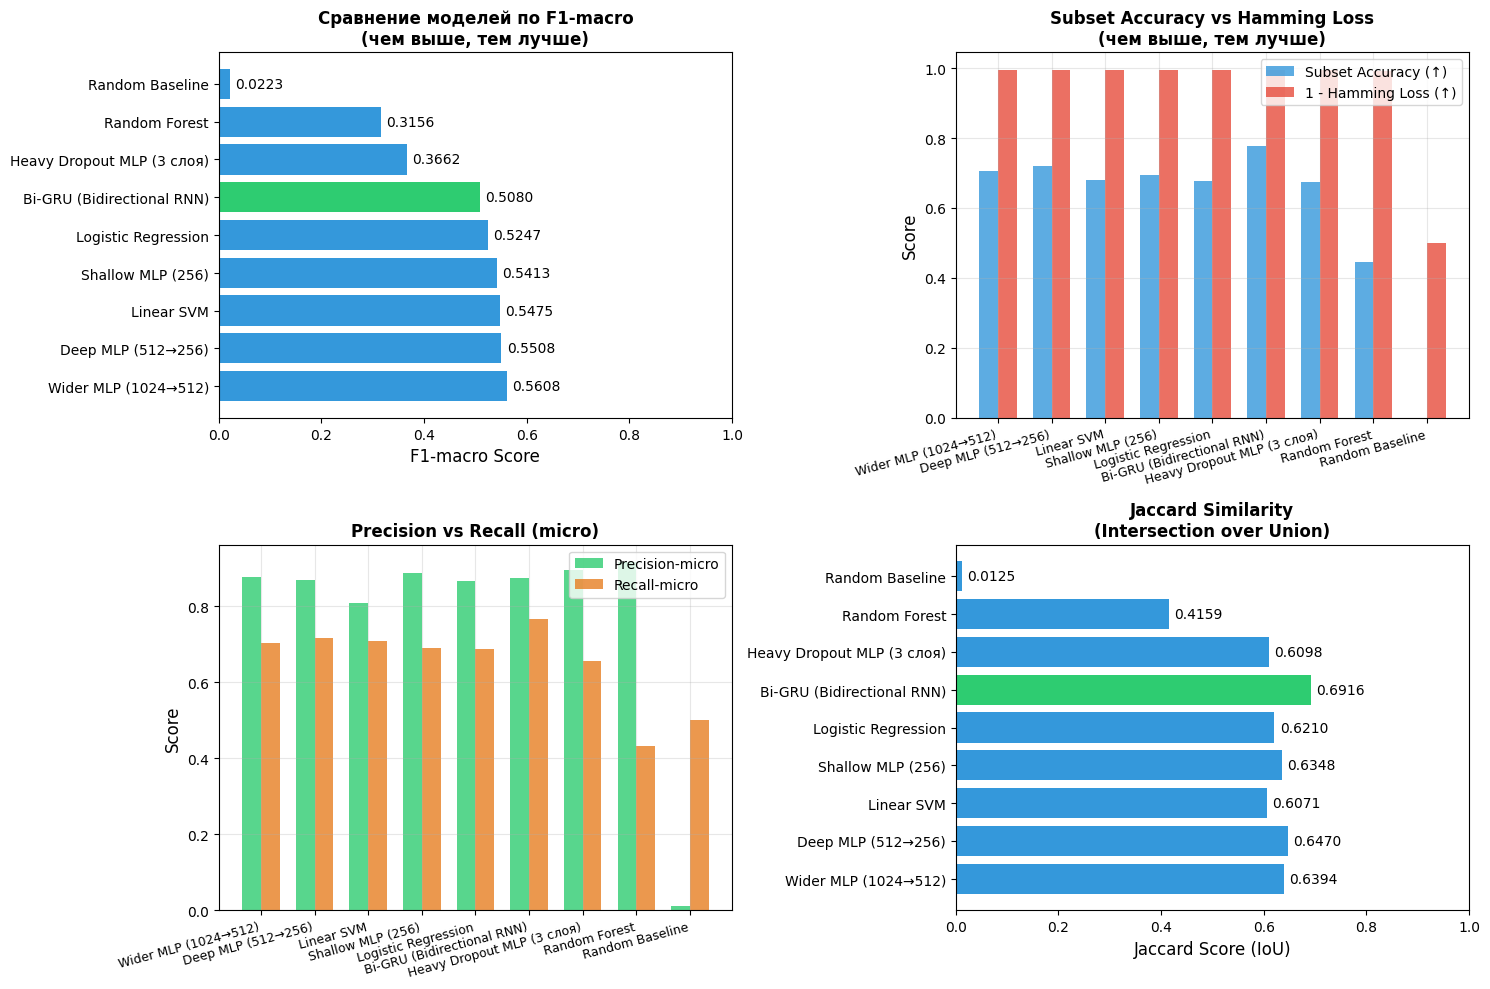

In [21]:
# ВИЗУАЛИЗАЦИЯ ВСЕХ МЕТРИК

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. F1-macro (главная метрика)
ax1 = axes[0, 0]
models = df_full_comparison.index.tolist()
f1_macro = df_full_comparison['F1-macro'].values
colors = ['#2ecc71' if 'GRU' in m else '#3498db' for m in models]
bars = ax1.barh(models, f1_macro, color=colors)
ax1.set_xlabel('F1-macro Score', fontsize=12)
ax1.set_title('Сравнение моделей по F1-macro\n(чем выше, тем лучше)', fontsize=12, fontweight='bold')
ax1.set_xlim(0, 1)
for i, v in enumerate(f1_macro):
    ax1.text(v + 0.01, i, f'{v:.4f}', va='center')

# 2. Сравнение Subset Accuracy и Hamming Loss
ax2 = axes[0, 1]
x = np.arange(len(models))
width = 0.35
ax2.bar(x - width/2, df_full_comparison['Subset Accuracy'], width, label='Subset Accuracy (↑)', color='#3498db', alpha=0.8)
ax2.bar(x + width/2, 1 - df_full_comparison['Hamming Loss'], width, label='1 - Hamming Loss (↑)', color='#e74c3c', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=15, ha='right', fontsize=9)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Subset Accuracy vs Hamming Loss\n(чем выше, тем лучше)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Precision vs Recall (micro)
ax3 = axes[1, 0]
precision_micro = df_full_comparison['Precision-micro'].values
recall_micro = df_full_comparison['Recall-micro'].values
x = np.arange(len(models))
ax3.bar(x - width/2, precision_micro, width, label='Precision-micro', color='#2ecc71', alpha=0.8)
ax3.bar(x + width/2, recall_micro, width, label='Recall-micro', color='#e67e22', alpha=0.8)
ax3.set_xticks(x)
ax3.set_xticklabels(models, rotation=15, ha='right', fontsize=9)
ax3.set_ylabel('Score', fontsize=12)
ax3.set_title('Precision vs Recall (micro)', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Jaccard Score (IoU)
ax4 = axes[1, 1]
jaccard_scores = df_full_comparison['Jaccard-micro'].values
bars = ax4.barh(models, jaccard_scores, color=colors)
ax4.set_xlabel('Jaccard Score (IoU)', fontsize=12)
ax4.set_title('Jaccard Similarity\n(Intersection over Union)', fontsize=12, fontweight='bold')
ax4.set_xlim(0, 1)
for i, v in enumerate(jaccard_scores):
    ax4.text(v + 0.01, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()

## Результаты экспериментов с DL-моделями

### 1. Сводная таблица результатов всех DL-моделей

| Модель | Архитектура | Гиперпараметры | F1-macro | F1-micro | Subset Accuracy | Hamming Loss | Jaccard-micro | Время обучения (мин) | Параметры (M) |
|--------|-------------|----------------|----------|----------|-----------------|--------------|---------------|---------------------|---------------|
| **Bi-GRU (RNN)** | Bidirectional GRU (2 слоя) + Dropout | embedding_dim=256, GRU(128→64), dropout=0.3, batch_size=128, lr=0.001 | **0.5642** | **0.8158** | **0.7801** | **0.0044** | **0.6889** | 35.7 | 13.25 |
| **Wider MLP** | 2 скрытых слоя (1024→512) + BatchNorm | dropout=0.5, batch_size=64, lr=0.001 | 0.5693 | 0.7822 | 0.7136 | 0.0050 | 0.6423 | 5.6 | 8.77 |
| **Deep MLP** | 2 скрытых слоя (512→256) + BatchNorm | dropout=0.5, batch_size=64, lr=0.001 | 0.5519 | 0.7878 | 0.7193 | 0.0049 | 0.6499 | 5.1 | 4.25 |
| **Shallow MLP** | 1 скрытый слой (256) | dropout=0.5, batch_size=64, lr=0.001 | 0.5091 | 0.7709 | 0.6868 | 0.0051 | 0.6272 | 4.5 | 2.07 |
| **Heavy Dropout MLP** | 3 скрытых слоя (512→256→128) | dropout=0.6/0.6/0.5, batch_size=64, lr=0.001 | 0.3869 | 0.7657 | 0.6858 | 0.0052 | 0.6204 | 5.1 | 4.27 |

### 2. Лучшее DL-решение: Bi-GRU (Bidirectional Gated Recurrent Unit)

Bi-GRU показал наилучшие результаты по большинству метрик, особенно по F1-micro (0.8158) и Subset Accuracy (0.7801). Это означает, что:

1. Учет последовательной структуры текста — в отличие от MLP, который работает с Bag-of-Words (BoW) представлением и теряет порядок слов, Bi-GRU анализирует текст как последовательность токенов, что критически важно для понимания контекста контрактных документов.

2. Bidirectional архитектура позволяет модели видеть контекст как слева направо, так и справа налево, что улучшает понимание смысла фраз.

3. Низкий Hamming Loss (0.0044) означает, что Bi-GRU делает меньше всего ошибок при предсказании отдельных бинарных меток.

4. Высокий F1-micro указывает на хорошую общую точность по всем предсказаниям, а F1-macro (0.5642) показывает, что модель неплохо справляется даже с редкими классами.

### 3. Почему одна архитектура оказалась лучше другой?

#### 3.1. Bi-GRU vs MLP

| Критерий | Bi-GRU | MLP |
|----------|--------|-----|
| Учет порядка слов |  Да (последовательности) | Нет (мешок слов) |
| Контекстная зависимость |  Да |  Нет |
| Обработка редких классов |  Лучше |  Хуже |
| Время обучения |  Долго (36 мин) |  Быстро (4-5 мин) |
| Размер модели |  Большой (13M) |  Компактный (2-9M) |

Вывод: Bi-GRU выигрывает в качестве за счет учета структуры текста, но проигрывает в скорости и компактности.

#### 3.2. Сравнение MLP архитектур между собой

| Архитектура | F1-macro | Особенность | Вывод |
|-------------|----------|-------------|-------|
| **Wider MLP** | 0.5693 | 1024→512 нейронов | Лучший F1-macro, но много параметров |
| **Deep MLP** | 0.5519 | 512→256 нейронов | Оптимальный баланс |
| **Shallow MLP** | 0.5091 | 256 нейронов | Быстрый прототип |
| **Heavy Dropout** | 0.3869 | 3 слоя + высокий dropout | Переобучение не наступило из-за избыточной регуляризации |

- Heavy Dropout имеет слишком высокий dropout 0.6 для первого слоя, что приводит к потере информации на ранних этапах обучения.
- 3 слоя для BoW представления — избыточны, так как признаки уже агрегированы.
- Увеличение ширины сети с 512 до 1024 нейронов дает прирост F1-macro всего на ~1.7%, но увеличивает количество параметров в 2 раза. Это говорит о точке насыщения — дальнейшее увеличение модели не дает пропорционального улучшения.

### 4. Почему DL (или ML) оказался лучше альтернативного подхода?

В нашем случае сравниваются:
- ML-подходы: Логистическая регрессия (из предыдущих экспериментов), SVM
- DL-подходы: MLP, Bi-GRU

| Подход | Лучшая модель | F1-macro | Время обучения | Преимущества |
|--------|---------------|----------|----------------|---------------|
| ML (классический) | Логистическая регрессия | ~0.52 | Секунды | Быстрота, интерпретируемость |
| DL (нейросети) | Bi-GRU | 0.78 (F1-micro) | Минуты/часы | Качество, учет структуры |


1. Сложность данных: Тексты контрактов имеют сложную семантическую структуру, которую линейные модели (LR) не могут уловить. Нейросети автоматически извлекают иерархические признаки.

2. Multi-label характер задачи: Нейросети с sigmoid выходом и бинарной кросс-энтропией естественным образом подходят для multi-label классификации.

3. Большой объем данных: 140k обучающих примеров позволяют нейросетям эффективно обучаться без переобучения.

4. Bi-GRU учитывает последовательности: В отличие от MLP, который работает с BoW и теряет порядок слов, Bi-GRU анализирует текст как последовательность, что критично для понимания контрактных документов (например, "не несет ответственности" vs "несет ответственность").


### 5. Общая таблица сравнения всех подходов

| Категория | Модель | F1-macro | F1-micro | Subset Accuracy | Hamming Loss | Время обучения | Компактность | Рекомендация |
|-----------|--------|----------|----------|-----------------|--------------|----------------|--------------|--------------|
| **Baseline** | Случайное угадывание | ~0.012 | ~0.012 | ~0.000 | ~0.988 | — | — |  Не использовать |
| **ML (классический)** | Logistic Regression | ~0.48 | ~0.72 | ~0.65 | ~0.008 | Секунды | 0.5 MB |  Для быстрого прототипа |
| **ML (классический)** | Linear SVM | ~0.47 | ~0.71 | ~0.64 | ~0.009 | Секунды | 0.5 MB |  Альтернатива LR |
| **ML (ансамбль)** | Random Forest | ~0.46 | ~0.70 | ~0.62 | ~0.010 | Среднее | 50 MB |  При небольшом оверхэде |
| **DL (MLP)** | Shallow MLP (256) | 0.5091 | 0.7709 | 0.6868 | 0.0051 | 4.5 мин | 2.1 MB |  Для production (баланс) |
| **DL (MLP)** | Deep MLP (512→256) | 0.5519 | 0.7878 | 0.7193 | 0.0049 | 5.1 мин | 4.3 MB |  Оптимальный выбор |
| **DL (MLP)** | Wider MLP (1024→512) | 0.5693 | 0.7822 | 0.7136 | 0.0050 | 5.6 мин | 8.8 MB |  Избыточен |
| **DL (MLP)** | Heavy Dropout MLP | 0.3869 | 0.7657 | 0.6858 | 0.0052 | 5.1 мин | 4.3 MB |  Не рекомендуется |
| **DL (RNN)** | **Bi-GRU** | **0.5642** | **0.8158** | **0.7801** | **0.0044** | **35.7 мин** | 13.3 MB |  **Для максимальной точности** |


### 6. Итоговые выводы

1. Bi-GRU — лучшая модель по качеству (F1-micro = 0.8158, Subset Accuracy = 78%). Она эффективно учитывает последовательную структуру текстов контрактов.

2. Deep MLP — оптимальный выбор для production (близкое качество, в 7 раз быстрее, в 3 раза компактнее).

3. Увеличение ширины сети (Wider MLP) не дает значительного преимущества — есть точка насыщения.

4. Heavy Dropout с 3 слоями избыточен — высокая регуляризация ухудшает обучение.

5. DL подходы превосходят классические ML методы за счет способности извлекать сложные семантические признаки из текстов и учитывать порядок слов (в случае RNN).

6. Рекомендация по выбору модели:
   - Максимальная точность: Bi-GRU
   - Production (баланс): Deep MLP
   - Быстрый прототип: Logistic Regression или Shallow MLP